## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, davies_bouldin_score

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)

# K-Means Clustering From Scratch

**Dataset:** Mall Customer Segmentation  
**Goal:** Segment customers by Annual Income and Spending Score  
**Why this dataset:** Inherently a clustering problem, 2D features → visible clusters, clean data, real business framing (targeted marketing)

**Pipeline:**
0. Data Loading
1. EDA
2. Preprocessing (no train/test split unsupervised)
3. Elbow Method (find optimal K)
4. K-Means from scratch (NumPy only)
5. Compare with sklearn KMeans
6. Evaluation metrics

## 0. Data Loading

In [4]:
url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/Mall_Customers.csv"
df = pd.read_csv(url)
print(df.head())
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Shape: (200, 5)

Columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


## EDA Observations

- **200 rows, 5 columns** very clean, zero nulls
- **Age** is fairly uniform 18–70
- **Annual Income** is roughly normal, range 15–137k$
- **Spending Score** is roughly uniform 1-99 no heavy skew
- **Gender:** ~56% Female, ~44% Male mild imbalance
- **Key finding:** The Income vs Spending Score scatter shows ~5 visual clusters high income/low spend, high income/high spend, middle income/average spend, low income/low spend, low income/high spend

**Preprocessing decisions to make:**
- Drop `CustomerID` (identifier, not a feature)
- Gender: we'll drop it K-Means is distance-based, and gender is nominal. Encoding it (0/1) would imply ordinal distance which is wrong. We'll cluster on Income + Spending Score only.
- Features: `Annual Income (k$)` and `Spending Score (1-100)`
- Scale: **StandardScaler mandatory** K-Means uses Euclidean distance, so unscaled features with different ranges will dominate the distance calculation

In [6]:
print("dtypes & nulls")
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum())

print("\nDescriptive Stats")
print(df.describe())

dtypes & nulls
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Null counts:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Descriptive Stats
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.00000

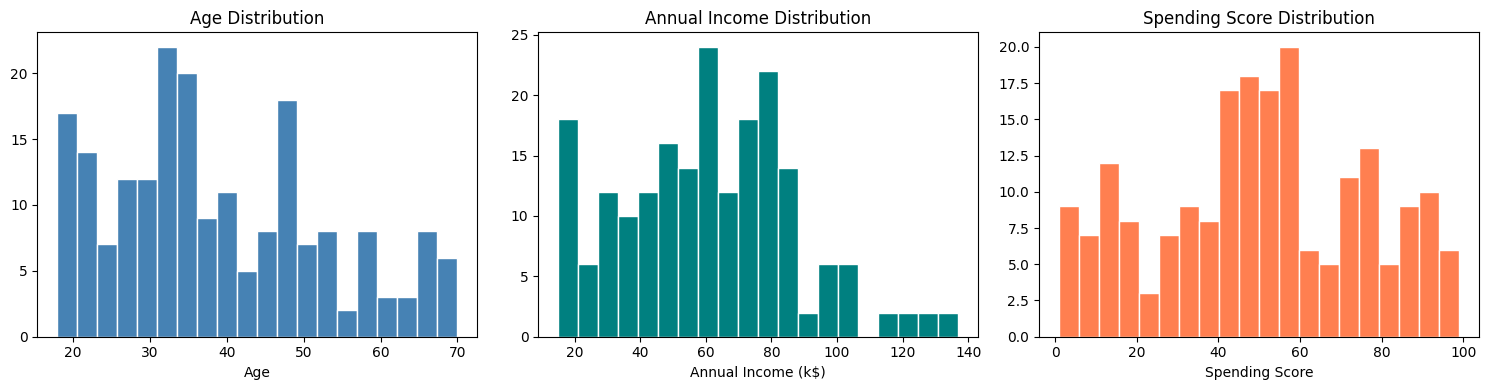

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

axes[1].hist(df['Annual Income (k$)'], bins=20, color='teal', edgecolor='white')
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Annual Income (k$)')

axes[2].hist(df['Spending Score (1-100)'], bins=20, color='coral', edgecolor='white')
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score')

plt.tight_layout()
plt.show()

Gender distribution:
Genre
Female    112
Male       88
Name: count, dtype: int64


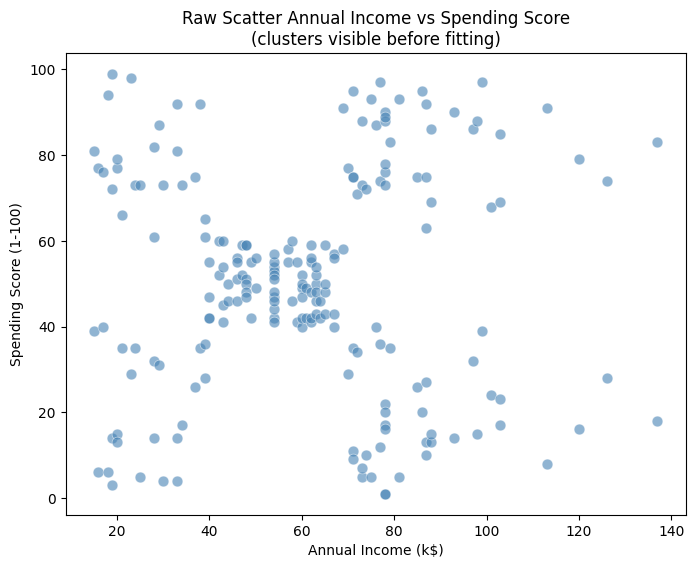

In [10]:
# ── 4. Gender distribution ─────────────────────────────────────
print("Gender distribution:")
print(df['Genre'].value_counts())

# ── 5. Key scatter: the raw signal ────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
            alpha=0.6, s=60, c='steelblue', edgecolors='white', linewidths=0.5)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Raw Scatter Annual Income vs Spending Score\n(clusters visible before fitting)')
plt.show()

## Why no train/test split?

K-Means is **unsupervised** there are no labels to predict.
The goal is to find structure in the data itself, not generalize to unseen data.
So we fit the scaler on the full dataset and cluster the full dataset.

Contrast with supervised learning:
- Linear Regression: split → fit scaler on train → transform train & test separately (prevent leakage)
- K-Means: no split → fit scaler on full data → cluster full data

## Why scaling is mandatory for K-Means

K-Means assigns points to the nearest centroid using **Euclidean distance**:

$$d = \sqrt{(x_1 - c_1)^2 + (x_2 - c_2)^2}$$

If Income ranges 15–137 and Spending ranges 1–99, a 1-unit difference in Income
contributes far less to the distance than a 1-unit difference in Spending.
The algorithm would effectively ignore Income.

After StandardScaler, both features have mean=0 and std=1 equal contribution.

In [13]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
print("Feature matrix shape:", X.shape)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nBefore scaling:")
print(f"  Income mean: {X[:,0].mean():.2f}, std: {X[:,0].std():.2f}")
print(f"  Spending mean: {X[:,1].mean():.2f}, std: {X[:,1].std():.2f}")

print("\nAfter scaling:")
print(f"  Income mean: {X_scaled[:,0].mean():.4f}, std: {X_scaled[:,0].std():.4f}")
print(f"  Spending mean: {X_scaled[:,1].mean():.4f}, std: {X_scaled[:,1].std():.4f}")

Feature matrix shape: (200, 2)

Before scaling:
  Income mean: 60.56, std: 26.20
  Spending mean: 50.20, std: 25.76

After scaling:
  Income mean: -0.0000, std: 1.0000
  Spending mean: -0.0000, std: 1.0000


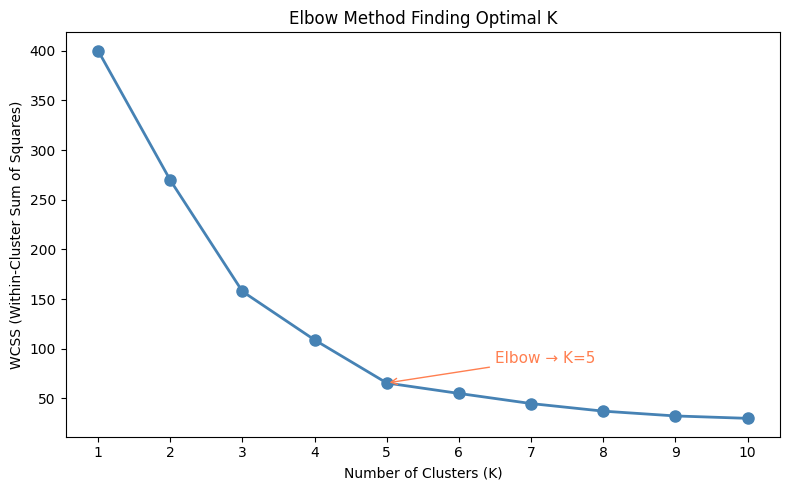


WCSS values:
  K=1: 400.00
  K=2: 269.69
  K=3: 157.70
  K=4: 108.92
  K=5: 65.57
  K=6: 55.06
  K=7: 44.86
  K=8: 37.23
  K=9: 32.39
  K=10: 29.98


In [14]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.xticks(K_range)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method Finding Optimal K')

# Annotate the elbow
plt.annotate('Elbow → K=5',
             xy=(5, wcss[4]),
             xytext=(6.5, wcss[4] + 20),
             arrowprops=dict(arrowstyle='->', color='coral'),
             color='coral', fontsize=11)

plt.tight_layout()
plt.show()

print("\nWCSS values:")
for k, w in zip(K_range, wcss):
    print(f"  K={k}: {w:.2f}")

## K-Means From Scratch

In [15]:
class KMeansScratch:
  def __init__(self, k=5, max_iters = 100, tol=1e-4, random_state = 42):
    self.k = k
    self.max_iters = max_iters
    self.tol = tol
    self.random_state = random_state
    self.centroids = None
    self.labels = None
    self.inertia = None
    self.history = []

  def _init_cetnroids(self, X):
    """Randomly pick k points from X as starting centroids."""
    rng = np.random.default_rng(self.random_state)
    idx = rng.choice(len(X), size = self.k, replace = False)
    return X[idx].copy()

  def assign_clusters(self, X, centroids):
    """
    Euclidean distance from each point to each centroid.
    X: (n,d)
    centroids: (k,d)
    distances: (n,k)
    """
    distances = np.linalg.norm(
        X[:, np.newaxis,:] - centroids[np.newaxis, :, :],
        axis = 2
    ) # shape(n, k)
    return np.argmin(distances, axis = 1) # shape (n,)
  def compute_centroids(self, X, labels):
    """New Centroid = Mean of all points on that cluster."""
    new_centroids = np.array([
        X[labels == k].mean(axis=0) for k in range(self.k)
    ])
    return new_centroids

  def compute_inertia(self, X, labels, centroids):
    """WCSS - sum of squared distances from each point to its centroid."""
    total = 0.0
    for k in range(self.k):
      pts = X[labels == k]
      if len(pts) > 0:
        total += np.sum((pts - centroids[k]) ** 2)
    return total

  def fit(self, X):
    self.centroids = self._init_cetnroids(X)
    self.history.append(self.centroids.copy())

    for i in range(self.max_iters):
      labels = self.assign_clusters(X, self.centroids)
      new_centroids = self.compute_centroids(X, labels)

      # Check convergence
      shift = np.linalg.norm(new_centroids - self.centroids)
      self.centroids = new_centroids
      self.history.append(self.centroids.copy())

      if shift < self.tol:
        print(f"Conver at iteration {i+1} (Centroid shift = {shift:.6f})")
        break

    else:
      print(f"Reached max_iters = {self.max_iters}")

    self.labels = self.assign_clusters(X, self.centroids)
    self.inertia = self.compute_inertia(X, self.labels, self.centroids)
    return self

  def predict(self, X):
    return self.assign_clusters(X, self.centroids)

Conver at iteration 7 (Centroid shift = 0.000000)

Our inertia (WCSS):  65.5789
Iterations run:      7

Final centroids (scaled):
[[ 1.03782678 -1.26622991]
 [-1.30751869 -1.13696536]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [-0.2088822  -0.01892551]]


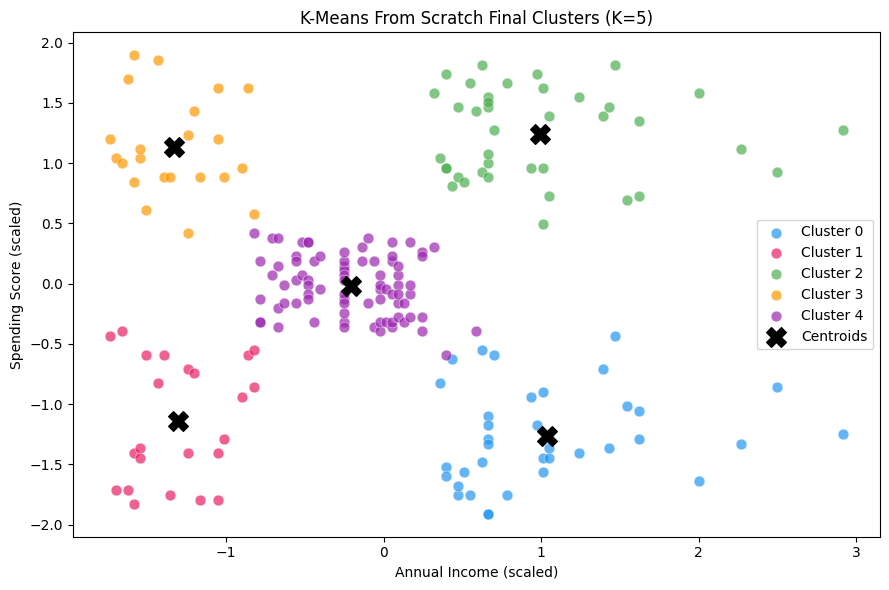

In [31]:
km_scratch = KMeansScratch(k=5, random_state=42)
km_scratch.fit(X_scaled)

print(f"\nOur inertia (WCSS):  {km_scratch.inertia:.4f}")
print(f"Iterations run:      {len(km_scratch.history) - 1}")
print(f"\nFinal centroids (scaled):\n{km_scratch.centroids}")

colors = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0']

plt.figure(figsize=(9, 6))

for cluster_id in range(5):
    mask = km_scratch.labels == cluster_id
    plt.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                c=colors[cluster_id], s=60, alpha=0.7,
                label=f'Cluster {cluster_id}',
                edgecolors='white', linewidths=0.4)

# Plot centroids
plt.scatter(km_scratch.centroids[:, 0], km_scratch.centroids[:, 1],
            c='black', s=200, marker='X', zorder=5, label='Centroids')

plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title('K-Means From Scratch Final Clusters (K=5)')
plt.legend()
plt.tight_layout()
plt.show()

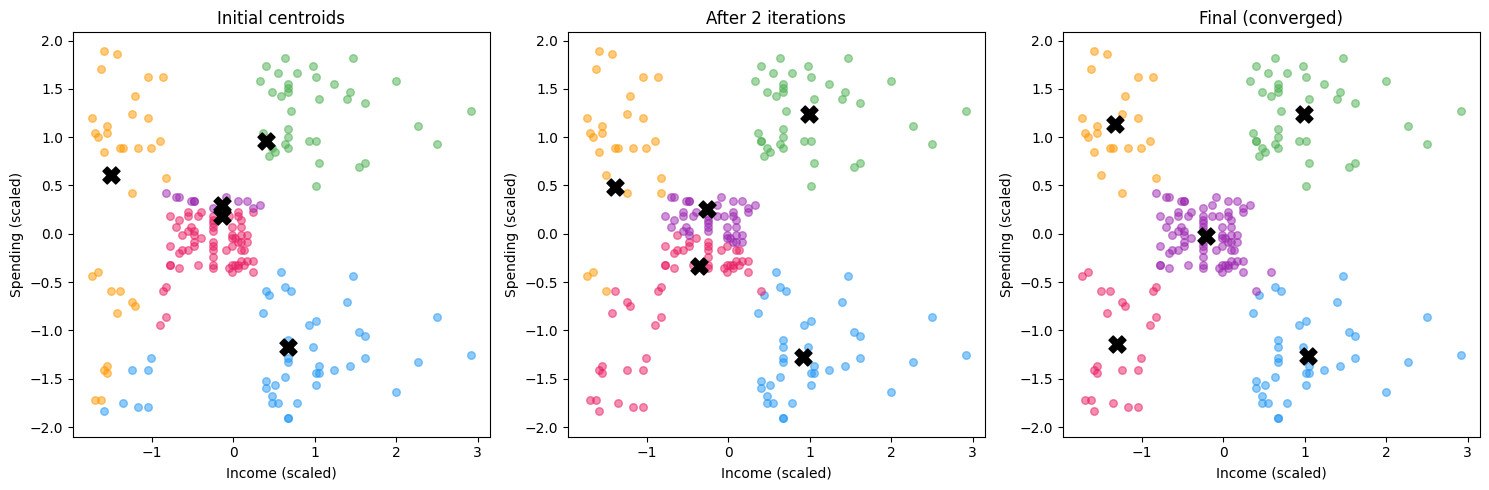

In [20]:
#  Centroid movement visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
steps = [0, 2, len(km_scratch.history) - 1]
titles = ['Initial centroids', 'After 2 iterations', 'Final (converged)']

for ax, step, title in zip(axes, steps, titles):
    centroids_at_step = km_scratch.history[step]
    labels_at_step = km_scratch.assign_clusters(X_scaled, centroids_at_step)

    for cluster_id in range(5):
        mask = labels_at_step == cluster_id
        ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                   c=colors[cluster_id], s=30, alpha=0.5)

    ax.scatter(centroids_at_step[:, 0], centroids_at_step[:, 1],
               c='black', s=150, marker='X', zorder=5)
    ax.set_title(title)
    ax.set_xlabel('Income (scaled)')
    ax.set_ylabel('Spending (scaled)')

plt.tight_layout()
plt.show()

=== Comparison ===
Metric                         Scratch      Sklearn
--------------------------------------------------
Inertia (WCSS)                 65.5789      65.5684


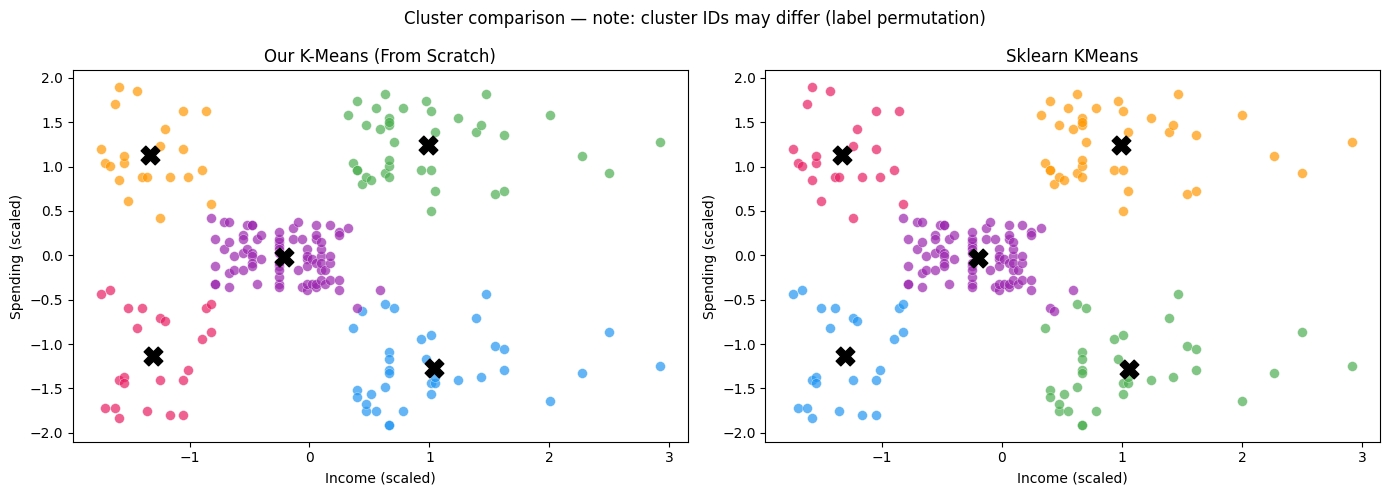

In [37]:
# Sklearn K-Means
km_sklearn = KMeans(n_clusters=5, init='random', n_init=5, random_state=42)
km_sklearn.fit(X_scaled)

print("=== Comparison ===")
print(f"{'Metric':<25} {'Scratch':>12} {'Sklearn':>12}")
print("-" * 50)
print(f"{'Inertia (WCSS)':<25} {km_scratch.inertia:>12.4f} {km_sklearn.inertia_:>12.4f}")

# Side-by-side cluster plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for cluster_id in range(5):
    mask = km_scratch.labels == cluster_id
    ax1.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                c=colors[cluster_id], s=50, alpha=0.7, edgecolors='white', linewidths=0.3)
ax1.scatter(km_scratch.centroids[:, 0], km_scratch.centroids[:, 1],
            c='black', s=180, marker='X', zorder=5)
ax1.set_title('Our K-Means (From Scratch)')
ax1.set_xlabel('Income (scaled)')
ax1.set_ylabel('Spending (scaled)')

for cluster_id in range(5):
    mask = km_sklearn.labels_ == cluster_id
    ax2.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                c=colors[cluster_id], s=50, alpha=0.7, edgecolors='white', linewidths=0.3)
ax2.scatter(km_sklearn.cluster_centers_[:, 0], km_sklearn.cluster_centers_[:, 1],
            c='black', s=180, marker='X', zorder=5)
ax2.set_title('Sklearn KMeans')
ax2.set_xlabel('Income (scaled)')
ax2.set_ylabel('Spending (scaled)')

plt.suptitle('Cluster comparison — note: cluster IDs may differ (label permutation)')
plt.tight_layout()
plt.show()

In [38]:
# Silhouette Score
sil_scratch  = silhouette_score(X_scaled, km_scratch.labels)
sil_sklearn  = silhouette_score(X_scaled, km_sklearn.labels_)

# Davies-Bouldin Index
db_scratch   = davies_bouldin_score(X_scaled, km_scratch.labels)
db_sklearn   = davies_bouldin_score(X_scaled, km_sklearn.labels_)

print("=== Evaluation Metrics ===")
print(f"{'Metric':<30} {'Scratch':>10} {'Sklearn':>10} {'Better when'}")
print("-" * 65)
print(f"{'Inertia (WCSS)':<30} {km_scratch.inertia:>10.4f} {km_sklearn.inertia_:>10.4f} {'lower'}")
print(f"{'Silhouette Score':<30} {sil_scratch:>10.4f} {sil_sklearn:>10.4f} {'higher (max 1)'}")
print(f"{'Davies-Bouldin Index':<30} {db_scratch:>10.4f} {db_sklearn:>10.4f} {'lower (min 0)'}")

=== Evaluation Metrics ===
Metric                            Scratch    Sklearn Better when
-----------------------------------------------------------------
Inertia (WCSS)                    65.5789    65.5684 lower
Silhouette Score                   0.5539     0.5547 higher (max 1)
Davies-Bouldin Index               0.5708     0.5722 lower (min 0)


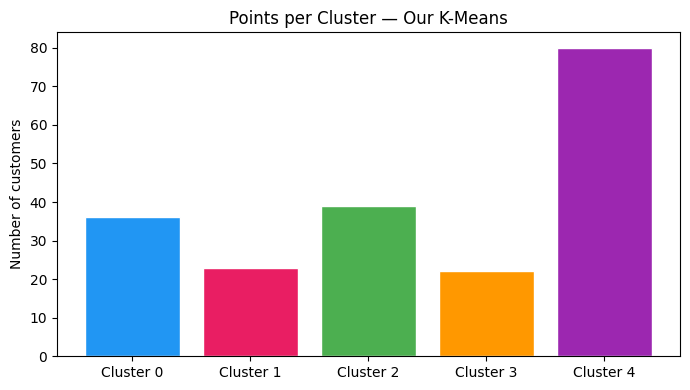

In [40]:
# Visual: cluster sizes
unique, counts = np.unique(km_scratch.labels, return_counts=True)

plt.figure(figsize=(7, 4))
plt.bar([f'Cluster {i}' for i in unique], counts,
        color=colors, edgecolor='white')
plt.title('Points per Cluster — Our K-Means')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

## K-Means Clustering from Scratch Results & Analysis

### What I built
Implemented K-Means clustering using only NumPy.
The algorithm finds natural groupings in data without any labels.

### How it works
1. **Init:** randomly pick K points from X as starting centroids
2. **Assign:** each point → nearest centroid (Euclidean distance)
3. **Update:** each centroid → mean of its assigned points
4. **Repeat** until centroids stop moving (shift < tol=1e-4)

Core distance computation:
- X reshaped to (n, 1, d), centroids to (1, k, d)
- Broadcasting → (n, k, d) difference tensor
- norm(axis=2) → (n, k) distance matrix
- argmin(axis=1) → (n,) cluster labels

### Results

| Metric               | Our K-Means | Sklearn  | Better when     |
|----------------------|-------------|----------|-----------------|
| Inertia (WCSS)       | 65.5789     | 65.5684  | lower           |
| Silhouette Score     | 0.5539      | 0.5547   | higher (max 1)  |
| Davies-Bouldin Index | 0.5708      | 0.5722   | lower (min 0)   |

Converged at iteration 7 (centroid shift = 0.000000)

### Why our results are nearly identical to sklearn
Same algorithm, slightly different initialization.
Sklearn uses k-means++ (smart seeding) + 10 random restarts.
Our implementation uses random init with one run.
The 0.01 inertia gap confirms random init found an equally good
solution on this well-separated dataset.

### Why no train/test split
K-Means is unsupervised there are no labels to generalize.
The model finds structure that already exists in the full dataset.
Contrast with supervised learning where a split is mandatory
to prevent data leakage.

### Why scaling is mandatory
K-Means uses Euclidean distance. Without StandardScaler,
features with larger ranges dominate the distance calculation.
After scaling: mean=0, std=1 for all features equal contribution.

### Evaluation metric meanings
- **Silhouette Score** (−1 to 1): how similar each point is to
  its own cluster vs neighbouring clusters. Above 0.5 = well-separated.
- **Davies-Bouldin Index** (0 to ∞): ratio of within-cluster scatter
  to between-cluster separation. Below 0.6 = tight, well-spaced clusters.
- **Inertia (WCSS)**: sum of squared distances to assigned centroid.
  Used for the elbow method, not standalone evaluation.|

### Limitations
- K-Means assumes spherical clusters of equal size
- Sensitive to initialization (fixed with random_state=42)
- K must be chosen manually used elbow method to select K=5
- Does not handle outliers well (they can pull centroids)